In [8]:
# Cell 1: Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Set visual style
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# Load the Excel file (adjust file path if needed)
file_path = "Day100_Month5_Capstone.xlsx"
df = pd.read_excel(file_path, sheet_name="1_Raw_Data")

print("✅ Data loaded successfully")
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

✅ Data loaded successfully
Shape: (148, 11)
Columns: ['OrderID', 'OrderDate', 'City', 'Category', 'Product', 'UnitPrice', 'Qty', 'Revenue', 'ReturnFlag', 'CustomerType', 'Channel']


In [9]:
# Cell 2: B1 – Data validation and type conversion

# 1. Print shape, dtypes, null count
print("=== Data Overview ===")
print(f"Shape: {df.shape}\n")
print("Data types:")
print(df.dtypes)
print("\nNull count per column:")
print(df.isnull().sum())

# 2. Convert OrderDate to datetime
df["OrderDate"] = pd.to_datetime(df["OrderDate"])
print(f"\nOrderDate converted. New dtype: {df['OrderDate'].dtype}")

# 3. Validate Revenue = UnitPrice * Qty for all rows
# Calculate expected revenue
calculated_revenue = df["UnitPrice"] * df["Qty"]
# Check for mismatches (allow tiny floating tolerance)
mismatch = (abs(df["Revenue"] - calculated_revenue) > 0.01)
mismatch_count = mismatch.sum()

if mismatch_count == 0:
    print("\n✅ VALIDATION PASSED: Revenue = UnitPrice × Qty for all rows")
else:
    print(f"\n❌ VALIDATION FAILED: {mismatch_count} mismatches found")
    print(df[mismatch][["OrderID", "UnitPrice", "Qty", "Revenue", calculated_revenue]])

=== Data Overview ===
Shape: (148, 11)

Data types:
OrderID         object
OrderDate       object
City            object
Category        object
Product         object
UnitPrice        int64
Qty              int64
Revenue          int64
ReturnFlag      object
CustomerType    object
Channel         object
dtype: object

Null count per column:
OrderID         0
OrderDate       0
City            0
Category        0
Product         0
UnitPrice       0
Qty             0
Revenue         0
ReturnFlag      0
CustomerType    0
Channel         0
dtype: int64

OrderDate converted. New dtype: datetime64[ns]

✅ VALIDATION PASSED: Revenue = UnitPrice × Qty for all rows


✅ Heatmap saved as 'heatmap.png'


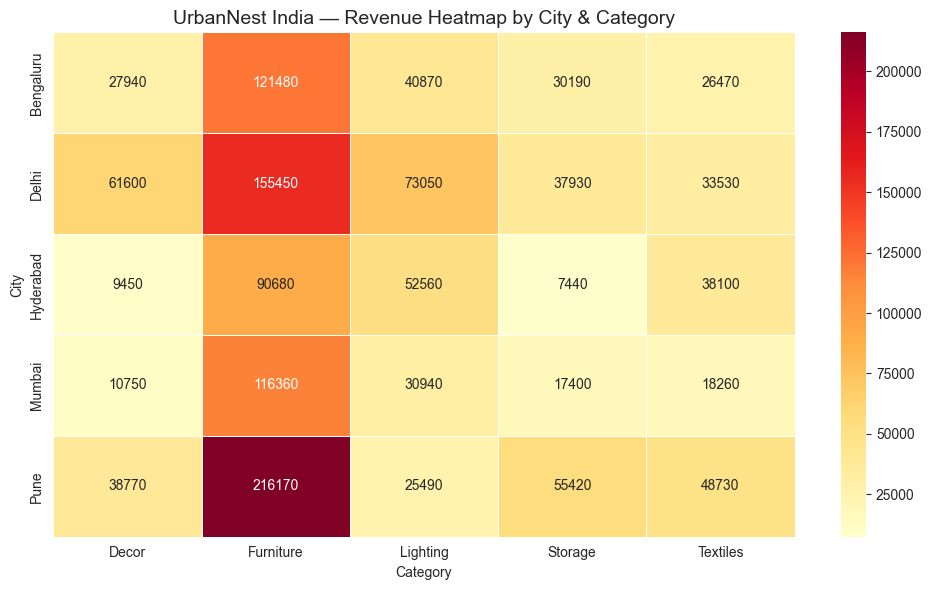

In [10]:
# Cell 3: B2 – Heatmap of Revenue by City and Category

# Create pivot table: rows = City, columns = Category, values = sum of Revenue
pivot_table = df.pivot_table(
    index="City",
    columns="Category",
    values="Revenue",
    aggfunc="sum",
    fill_value=0
)

# Plot heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(pivot_table, annot=True, fmt=".0f", cmap="YlOrRd", linewidths=0.5)
plt.title("UrbanNest India — Revenue Heatmap by City & Category", fontsize=14)
plt.ylabel("City")
plt.xlabel("Category")
plt.tight_layout()

# Save the figure
plt.savefig("heatmap.png", dpi=150)
print("✅ Heatmap saved as 'heatmap.png'")
plt.show()

✅ MoM line chart saved as 'mom_revenue.png'


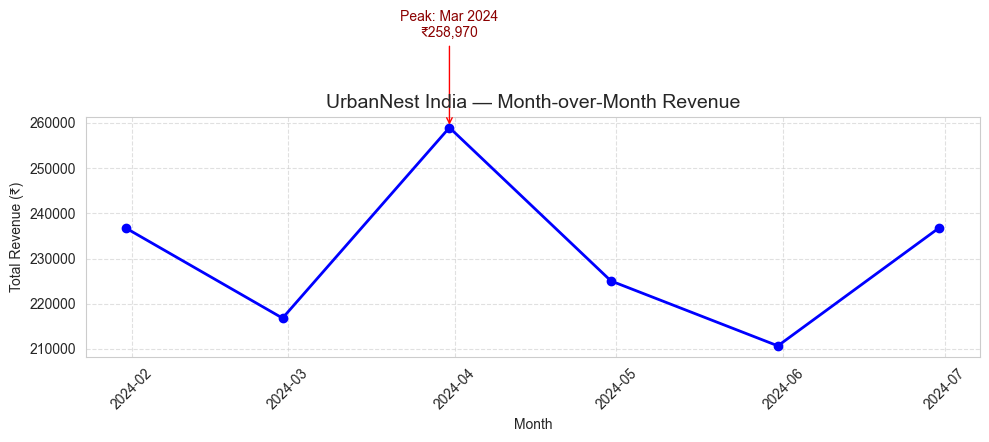

In [11]:
# Cell 4: B3 – Month-over-Month Revenue with annotation

# Set OrderDate as index for resampling
df_time = df.set_index("OrderDate")

# Group by month (end of month frequency)
monthly_revenue = df_time["Revenue"].resample("ME").sum()

# Convert to DataFrame for easier plotting
monthly_df = monthly_revenue.reset_index()
monthly_df.columns = ["Month", "Revenue"]

# Find the month with highest revenue
max_row = monthly_df.loc[monthly_df["Revenue"].idxmax()]
max_month = max_row["Month"].strftime("%b %Y")
max_revenue = max_row["Revenue"]

# Plot line chart with markers
plt.figure(figsize=(10, 5))
plt.plot(monthly_df["Month"], monthly_df["Revenue"], marker="o", linestyle="-", color="b", linewidth=2)

# Annotate highest month
plt.annotate(f"Peak: {max_month}\n₹{max_revenue:,.0f}",
             xy=(max_row["Month"], max_revenue),
             xytext=(max_row["Month"], max_revenue + 20000),
             arrowprops=dict(arrowstyle="->", color="red"),
             ha="center", fontsize=10, color="darkred")

plt.title("UrbanNest India — Month-over-Month Revenue", fontsize=14)
plt.xlabel("Month")
plt.ylabel("Total Revenue (₹)")
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()

# Save figure
plt.savefig("mom_revenue.png", dpi=150)
print("✅ MoM line chart saved as 'mom_revenue.png'")
plt.show()

✅ Channel performance chart saved as 'channel_performance.png'


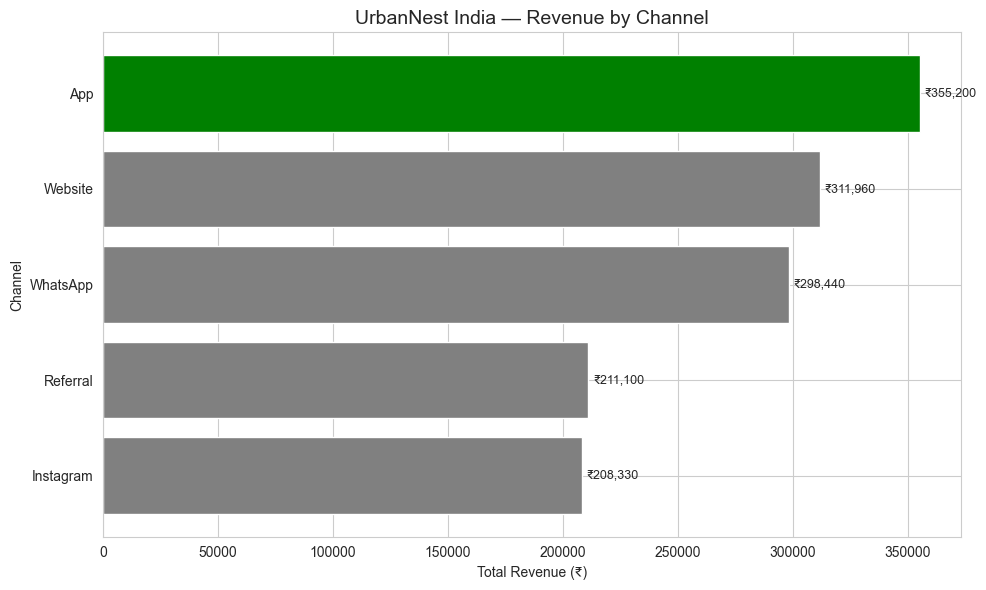

In [12]:
# Cell 5: B4 – Channel Performance (horizontal bar, top bar green)

# Group by Channel and sum Revenue, sort ascending for horizontal bar
channel_revenue = df.groupby("Channel")["Revenue"].sum().sort_values(ascending=True)

# Define colors: top bar (last in ascending order) green, others grey
colors = ["grey"] * len(channel_revenue)
colors[-1] = "green"   # highest revenue channel

# Plot horizontal bar chart
plt.figure(figsize=(10, 6))
bars = plt.barh(channel_revenue.index, channel_revenue.values, color=colors)

# Add value labels at the end of each bar
for bar in bars:
    width = bar.get_width()
    plt.text(width + 2000, bar.get_y() + bar.get_height()/2,
             f"₹{width:,.0f}", va="center", fontsize=9)

plt.title("UrbanNest India — Revenue by Channel", fontsize=14)
plt.xlabel("Total Revenue (₹)")
plt.ylabel("Channel")
plt.tight_layout()

# Save figure
plt.savefig("channel_performance.png", dpi=150)
print("✅ Channel performance chart saved as 'channel_performance.png'")
plt.show()

In [13]:
# Cell 6: B5 – Return Analysis: Count returns & lost revenue per category

# Filter rows where ReturnFlag = 'Yes'
returns_df = df[df["ReturnFlag"] == "Yes"]

# Group by Category to count returns and sum lost revenue
return_analysis = returns_df.groupby("Category")["Revenue"].agg(["count", "sum"])
return_analysis.columns = ["Return_Count", "Lost_Revenue"]

# Sort by lost revenue descending
return_analysis = return_analysis.sort_values("Lost_Revenue", ascending=False)

# Print as markdown table
print("### Return Analysis by Category\n")
print("| Category | Return Count | Lost Revenue (₹) |")
print("|----------|--------------|------------------|")
for idx, row in return_analysis.iterrows():
    print(f"| {idx} | {row['Return_Count']} | {row['Lost_Revenue']:,.0f} |")

# Identify highest-cost category
top_loss_category = return_analysis.index[0]
top_loss_amount = return_analysis.iloc[0]["Lost_Revenue"]

print(f"\n**NRA Insight:** {top_loss_category} costs the most in returns — ₹{top_loss_amount:,.0f} lost. "
      "Action: Prioritize quality control for this category to reduce return rate and retain revenue.")

### Return Analysis by Category

| Category | Return Count | Lost Revenue (₹) |
|----------|--------------|------------------|
| Furniture | 8 | 200,430 |
| Storage | 6 | 37,010 |
| Lighting | 5 | 32,270 |
| Textiles | 2 | 21,040 |
| Decor | 4 | 16,690 |

**NRA Insight:** Furniture costs the most in returns — ₹200,430 lost. Action: Prioritize quality control for this category to reduce return rate and retain revenue.


In [17]:
# Cell 7: B6 – New vs Returning Customer Revenue & % share

# Group by CustomerType and sum Revenue
customer_revenue = df.groupby("CustomerType")["Revenue"].sum()

# Compute % share of total
total_revenue = df["Revenue"].sum()
customer_share = (customer_revenue / total_revenue) * 100

# Create summary table
summary_df = pd.DataFrame({
    "Revenue (₹)": customer_revenue,
    "% Share": customer_share
})

print("### Customer Type Revenue Breakdown\n")
print(summary_df.to_markdown())

# NRA insight
dominant_type = customer_revenue.idxmax()
dominant_share = customer_share.max()
print(f"\n**NRA Insight:** {dominant_type} customers drive {dominant_share:.1f}% of total revenue. "
      f"Action: Launch a retention program (e.g., loyalty points, exclusive previews) for {dominant_type} "
      "and a welcome discount series to convert New customers faster.")

### Customer Type Revenue Breakdown

| CustomerType   |   Revenue (₹) |   % Share |
|:---------------|--------------:|----------:|
| New            |        816520 |   58.9532 |
| Returning      |        568510 |   41.0468 |

**NRA Insight:** New customers drive 59.0% of total revenue. Action: Launch a retention program (e.g., loyalty points, exclusive previews) for New and a welcome discount series to convert New customers faster.
